In [ ]:
import math
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [ ]:
SEED = 79

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

In [ ]:
class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, env):


        self.env = env
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_legal_actions(self, _state):
        return list(range(self.env.action_space.n))

    def get_qvalue(self, state, action):
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        self._qvalues[state][action] = value


    def get_value(self, state):

        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:
            return 0.0

        value = max([self.get_qvalue(state, action) for action in possible_actions])


        return value

    def update(self, state, action, reward, next_state, done=False, *args, **kwargs):
        gamma = self.discount

        #if done:
        #  target = reward
        #else:
        target = reward + gamma * self.get_value(next_state)

        old = self.get_qvalue(state, action)
        new_q = old + self.alpha * (target - old)

        self.set_qvalue(state, action, new_q)

    def get_best_action(self, state):

        possible_actions = self.get_legal_actions(state)

        if len(possible_actions) == 0:
            return None

        best_action = max(possible_actions, key=lambda action: self.get_qvalue(state, action))


        return best_action

    def get_action(self, state):

        possible_actions = self.get_legal_actions(state)
        action = None

        if len(possible_actions) == 0:
            return None

        if random.random() < self.epsilon:
          return random.choice(possible_actions)
        else:
          return self.get_best_action(state)



In [ ]:
class ProspectQLearningAgent(QLearningAgent):
    def __init__(self, alpha, epsilon, discount, env,
                 a=0.88, b=0.88, l=2.35):
        super().__init__(alpha, epsilon, discount, env)
        self.a = a
        self.b = b
        self.l = l

    def transform_reward(self, r):
        if r >= 0:
            return r ** self.a
        else:
            return -self.l * ((-r) ** self.b)

    def update(self, state, action, reward, next_state, done=False, *args, **kwargs):
        r_tilde = self.transform_reward(reward)

        if done:
            target = r_tilde
        else:
            target = r_tilde + self.discount * self.get_value(next_state)

        old = self.get_qvalue(state, action)
        new = old + self.alpha * (target - old)

        self.set_qvalue(state, action, new)

In [ ]:
class RiskSensitiveQLearningAgent(QLearningAgent):
    def __init__(self, alpha, epsilon, discount, env,
                 n=0.02, reward_scale=20.0):
        super().__init__(alpha, epsilon, discount, env)

        self.n = n
        self.reward_scale = reward_scale

        self._uvalues = defaultdict(lambda: defaultdict(lambda: 1.0))

    def get_uvalue(self, state, action):
        return self._uvalues[state][action]

    def set_uvalue(self, state, action, value):
        self._uvalues[state][action] = value

    def get_min_u(self, state):
        actions = self.get_legal_actions(state)
        if not actions:
            return 1.0
        return min(self.get_uvalue(state, a) for a in actions)

    def _scaled_reward(self, r):
        r = r / self.reward_scale
        return np.clip(r, -10, 10)

    def update(self, state, action, reward, next_state, done=False):
        n = self.n

        r = self._scaled_reward(reward)
        #r = reward
        if done:
          target = math.exp(-n * r)
        else:
          target = math.exp(-n * r) * self.get_min_u(next_state)

        old_u = max(self.get_uvalue(state, action), 1e-12)

        new_u = (1 - self.alpha) * old_u + self.alpha * target

        new_u = min(max(new_u, 1e-12), 1e6)

        self.set_uvalue(state, action, new_u)

        q = -(1.0 / n) * math.log(new_u)
        self.set_qvalue(state, action, q)

In [ ]:
def train(env, agent, t_max=10**4, seed=None):
    total_reward = 0.0
    s, _ = env.reset(seed=seed)

    for t in range(t_max):
        a = agent.get_action(s)
        next_s, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        agent.update(s, a, r, next_s, done=done)

        s = next_s
        total_reward += r

        if done:
            break

    return total_reward

In [ ]:
class DroneEnv:
    def __init__(self, seed=SEED):
        self.x_min, self.x_max = 0, 24
        self.y_min, self.y_max = 0, 12

        self.station_center = np.array([21.5, 8.5])
        self.station_radius = 0.9
        self.charge_rate = 0.025
        self.wind_range = 0.11

        self.obstacles = [
            (10.0, 2.0, 11.5, 5.5),
            (13.0, 7.0, 14.5, 10.0),
            (16.5, 3.5, 18.0, 6.5),
            (19.0, 9.0, 20.5, 11.5),
        ]

        self.speeds = [0.10, 0.25, 0.40]

        self.actions = []
        directions = [0, math.pi/2, math.pi, 3*math.pi/2]
        for direction in directions:
            for speed in self.speeds:
                self.actions.append((direction, speed))

        self.action_space = type('', (), {})()
        self.action_space.n = len(self.actions)
        self.last_speed = 0
        self.wind = np.array([0.0, 0.0])
        self.old_dist = 0
        self.new_dist = 0
        self.seed(seed)
        self.reset()

    def seed(self, seed=SEED):
        self.seed_value = seed
        self.rng = np.random.default_rng(seed)
        self.py_rng = random.Random(seed)
        return seed

    def reset(self, seed=None):
        if seed is not None:
            self.seed(seed)
        x = np.clip(self.rng.normal(3.5, 1.8), 1.0, 7.0)
        y = np.clip(self.rng.normal(6.0, 1.8), 2.0, 10.0)
        self.last_speed = 0.1
        self.pos = np.array([x, y])
        self.battery = 1.0
        self.energy_wasted = 0
        self.t = 0
        self._update_wind()

        return self._get_state(), {}

    def step(self, action_idx):
        direction, speed = self.actions[action_idx]
        self.last_speed = speed

        if self.t % 15 == 0:
            self._update_wind()
        self.old_dist = np.linalg.norm(self.pos - self.station_center)

        wx, wy = self.wind
        self.last_speed = speed
        new_x = self.pos[0] + speed * math.cos(direction) + wx
        new_y = self.pos[1] + speed * math.sin(direction) + wy

        new_x = np.clip(new_x, self.x_min, self.x_max)
        new_y = np.clip(new_y, self.y_min, self.y_max)


        collision = self._check_collision(new_x, new_y)

        if not collision:
            self.pos = np.array([new_x, new_y])

        self.new_dist = np.linalg.norm(self.pos - self.station_center)

        in_station = self.new_dist < self.station_radius

        wind_norm = np.linalg.norm(self.wind)
        battery_change =  - 0.018 * speed**2 - 0.003 * wind_norm**2 - 0.002 * abs(speed)
        charge = self.charge_rate if in_station else 0.0
        self.battery = min(
            1.0,
            self.battery
            + battery_change + charge
        )
        self.energy_wasted+=battery_change
        reward = self._compute_reward(speed, in_station)

        success = (self.new_dist < self.station_radius) and (self.battery > 0.9) and (self.t <= 140)
        fail = (self.battery < 0.04) or (self.t >= 200)
        info = {"collision": collision, "success":success}
        terminated = success or fail
        truncated = False

        if success:
            reward = 90
        elif fail:
            reward = -170

        self.t += 1

        return self._get_state(), reward, terminated, truncated, info

    def _update_wind(self):

      self.wind = np.array([
            self.py_rng.uniform(-self.wind_range, self.wind_range),
            self.py_rng.uniform(-self.wind_range, self.wind_range)
        ])


    def _compute_reward(self, speed, in_station):
        #return -1.0 - 0.03 * speed**2 + 1.0 * (self.old_dist-self.new_dist)   + (0.12 * 0.025 if in_station else 0)
        return -1.0 - 0.03 * speed**2  + (0.12 * 0.025 if in_station else 0)

    def _check_collision(self, x, y):
        for (x1, y1, x2, y2) in self.obstacles:
            if x1 <= x <= x2 and y1 <= y <= y2:
                return True
        return False


    def _get_state(self):
        dx = self.station_center[0] - self.pos[0]
        dy = self.station_center[1] - self.pos[1]

        dx_bin = int(np.clip((dx + 24) / 48 * 14, 0, 13))
        dy_bin = int(np.clip((dy + 12) / 24 * 14, 0, 13))
        b_bin = int(np.clip(self.battery * 10, 0, 9))

        #speed_bin = int(np.clip(self.last_speed * 5, 0, 4))
        speed_bin = self.speeds.index(self.last_speed)
        return (dx_bin, dy_bin, b_bin, speed_bin)

In [ ]:
def evaluate_agent(env, agent, n_episodes=300, seed=SEED + 100000):
    old_epsilon = agent.epsilon
    agent.epsilon = 0.005

    successes = 0
    times = []
    energies = []
    collisions = []

    for ep in range(n_episodes):
        s, _ = env.reset(seed=seed + ep)

        wasted_energy = 0
        episode_collisions = 0

        for t in range(300):
            a = agent.get_action(s)
            next_s, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated

            wasted_energy += (env.energy_wasted)

            if info.get("collision", False):
                episode_collisions += 1

            s = next_s

            if done:
                if info.get("success", False):
                    successes += 1
                    times.append(t)
                    energies.append(wasted_energy)
                    collisions.append(episode_collisions > 0)
                break

    agent.epsilon = old_epsilon

    return {
        "success_rate": successes / n_episodes,
        "mean_time": np.mean(times) if times else None,
        "mean_energy": np.mean(energies),
        "collision_rate": np.mean(collisions),
        "times": times,
        "energies": energies
    }

In [ ]:
def plot_learning_curve(rewards, window=150):
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')

    plt.figure()
    plt.plot(smoothed)
    plt.title("Learning Curve")
    plt.xlabel("Episode")
    plt.ylabel("Reward (moving avg)")
    plt.show()

In [ ]:
def plot_cdf(times):
    times = np.sort(times)
    cdf = np.arange(len(times)) / len(times)

    plt.figure()
    plt.plot(times, cdf)
    plt.title("CDF of Time to Success")
    plt.xlabel("Steps")
    plt.ylabel("CDF")
    plt.show()

In [ ]:
def plot_battery_heatmap(batteries):
    plt.figure()
    plt.hist(batteries, bins=20)
    plt.title("Final Battery Distribution")
    plt.xlabel("Battery")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
def get_trajectory(env, agent):
    s, _ = env.reset()
    traj = [env.pos.copy()]

    for _ in range(300):
        a = agent.get_action(s)
        s, _, done, _, _ = env.step(a)
        traj.append(env.pos.copy())
        if done:
            break

    return np.array(traj)

In [ ]:
def plot_trajectories(env, agent, n=4):
    plt.figure()

    for _ in range(n):
        traj = get_trajectory(env, agent)
        plt.plot(traj[:,0], traj[:,1])

    plt.title("Trajectories")
    plt.xlim(env.x_min, env.x_max)
    plt.ylim(env.y_min, env.y_max)
    plt.show()

In [ ]:
def compare_agents(metric1, metric2):
    stat, p = ttest_ind(metric1, metric2, equal_var=False)
    print("t-stat:", stat)
    print("p-value:", p)

    if p < 0.05:
        print("Различие статистически значимо")
    else:
        print("Различие не значимо")


===== Q-Learning =====
0 -370.45780000000013
200 -370.4758000000003
400 -370.45397500000024
600 -370.46747500000026
800 -370.4944750000002
1000 -370.4413750000003
1200 -370.4953750000002
1400 -370.45937500000014
1600 -370.4569000000003
1800 -370.48795000000035
2000 -370.48727500000007
2200 -370.51832499999983
2400 -370.51225
2600 -370.4209000000004
2800 -370.47085000000027
3000 -370.44205000000034
3200 -370.4701750000004
3400 -370.4731000000004
3600 -370.5032500000002
3800 -370.52664999999996
4000 -370.4782750000004
4200 -370.47512500000016
4400 -370.4501500000002
4600 -370.50685000000004
4800 -370.4296750000003
5000 -370.4422750000002
5200 -370.4546500000002
5400 -370.4926750000004
5600 -370.4533000000003
5800 -370.5052750000001
6000 -370.52889999999985
6200 -370.58695000000023
6400 -370.5889749999998
6600 -370.45330000000035
6800 -370.4359750000003
7000 -370.4434000000005
7200 -370.5424750000001
7400 -370.5365500000001
7600 -370.5203499999999
7800 -370.44700000000023
8000 -370.46230

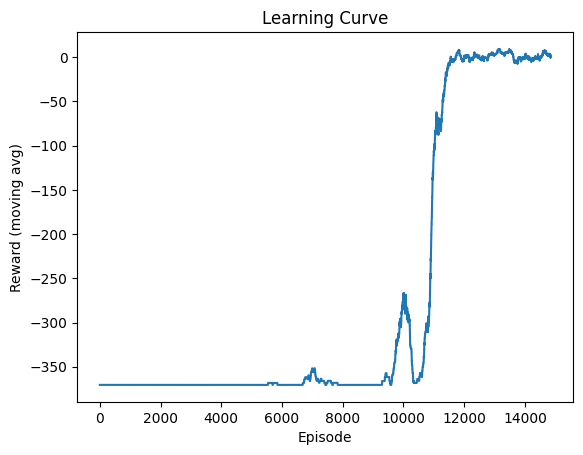

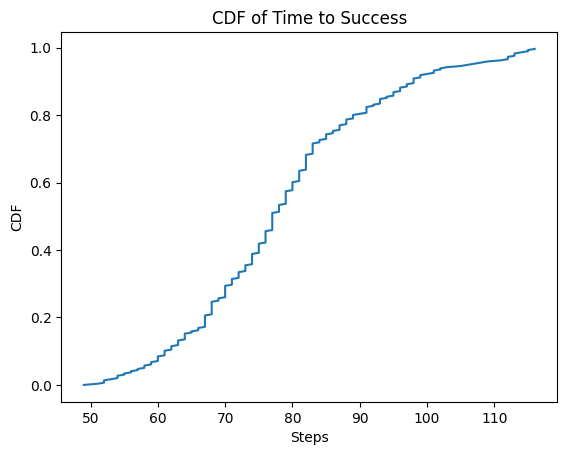

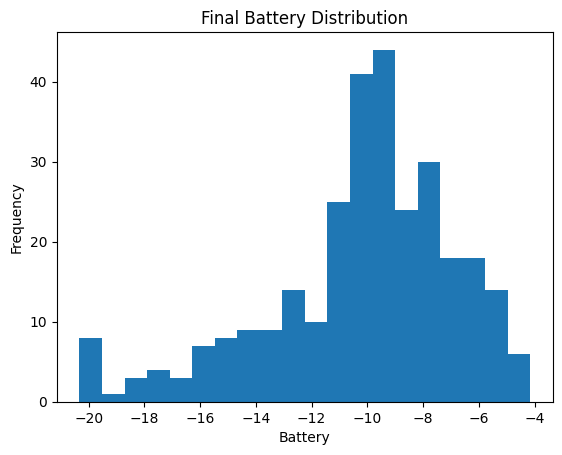

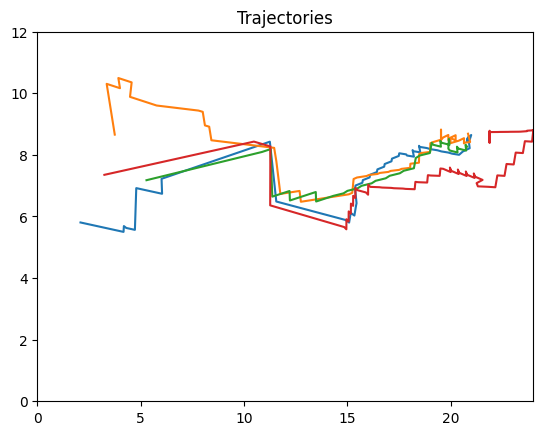


===== Prospect =====
0 -370.45780000000013
200 -370.46275000000026
400 -370.4798500000003
600 -370.48120000000034
800 -370.4926750000003
1000 -370.45127500000035
1200 -370.4803000000003
1400 -370.4794000000003
1600 -370.4440750000004
1800 -370.53430000000003
2000 -370.44452500000034
2200 -370.5138250000002
2400 -370.45150000000035
2600 -370.5210250000002
2800 -370.46117500000025
3000 -370.525075
3200 -370.53092500000014
3400 -370.54307500000004
3600 -370.4371000000003
3800 -370.503475
4000 -370.47310000000016
4200 -370.45262500000024
4400 -370.5064000000003
4600 -370.4834500000004
4800 -370.4611750000001
5000 -370.44880000000006
5200 -370.5295750000001
5400 -370.528
5600 -370.61170000000016
5800 -370.5052750000002
6000 -370.52890000000014
6200 -370.42495000000054
6400 -370.5478000000002
6600 -370.4728750000003
6800 -370.59549999999996
7000 -370.4843500000005
7200 -370.52080000000035
7400 -370.5687250000002
7600 -370.5374500000005
7800 -370.4542000000003
8000 -370.52462499999996
8200 -

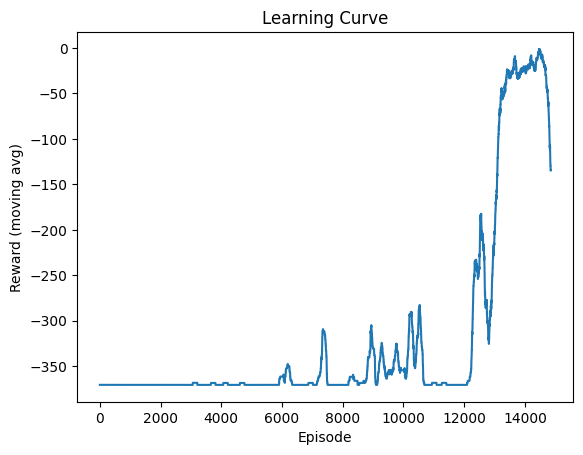

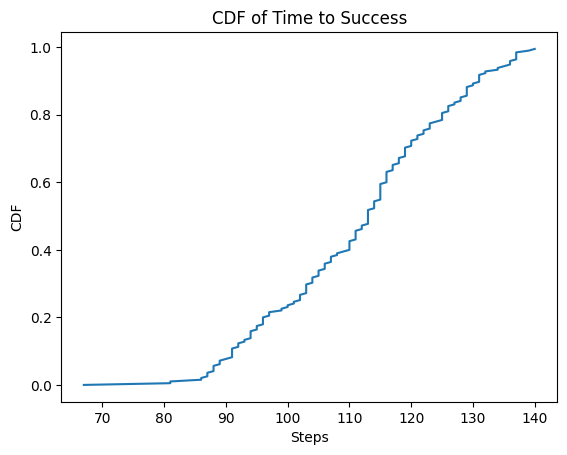

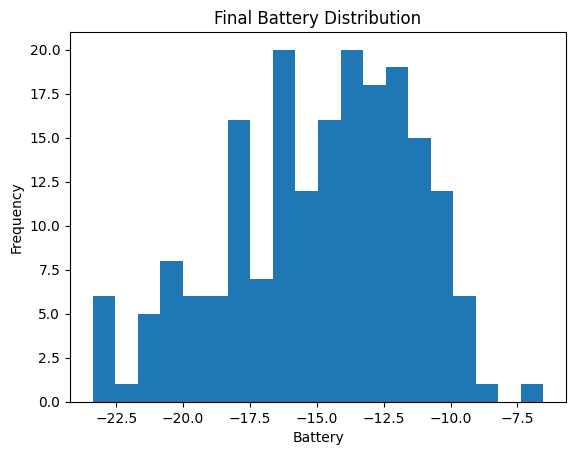

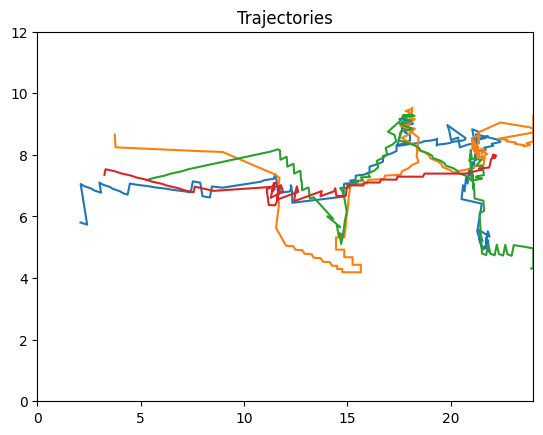


===== RiskSensitive =====
0 -370.45780000000013
200 -370.49267500000025
400 -370.4593750000003
600 -370.4535250000003
800 -370.5154000000003
1000 -370.4461000000001
1200 -370.4776000000002
1400 -370.4791750000002
1600 -370.4807500000003
1800 -370.43710000000016
2000 -370.4893000000003
2200 -370.49110000000024
2400 -370.4348500000003
2600 -370.4902000000002
2800 -370.5124750000002
3000 -370.5016750000002
3200 -370.49335000000013
3400 -370.5570250000002
3600 -370.49267499999996
3800 -370.4872750000003
4000 -370.4935750000001
4200 -370.4913250000002
4400 -370.47017500000027
4600 -370.453975
4800 -370.47940000000017
5000 -370.5590499999999
5200 -370.4872750000003
5400 -370.5066250000002
5600 -370.46905000000027
5800 -370.4994250000003
6000 -370.4839000000003
6200 -370.61125000000004
6400 -370.5046000000001
6600 -370.4463250000003
6800 -370.4809750000003
7000 -370.4908750000003
7200 -370.54330000000004
7400 -370.4893000000003
7600 -370.52147500000024
7800 -370.5136000000002
8000 -370.51225

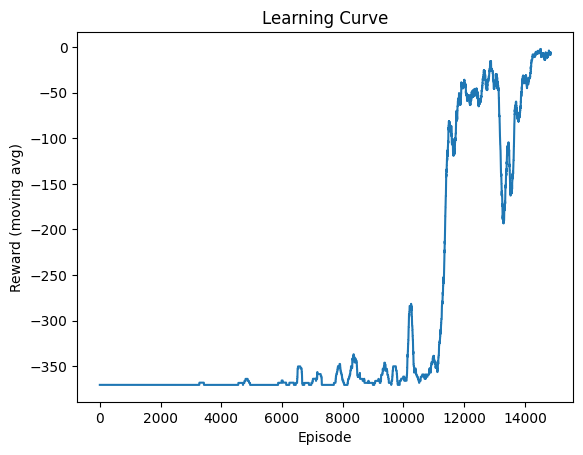

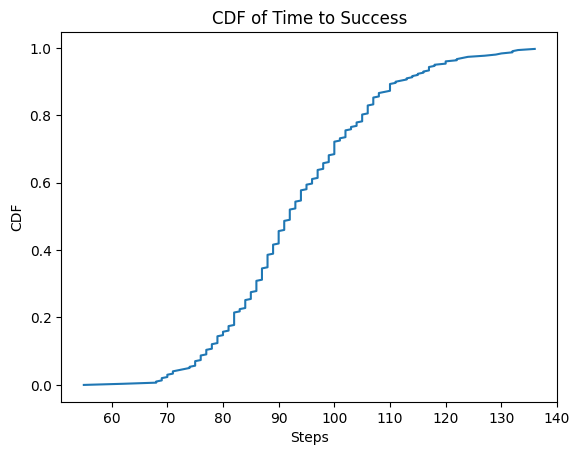

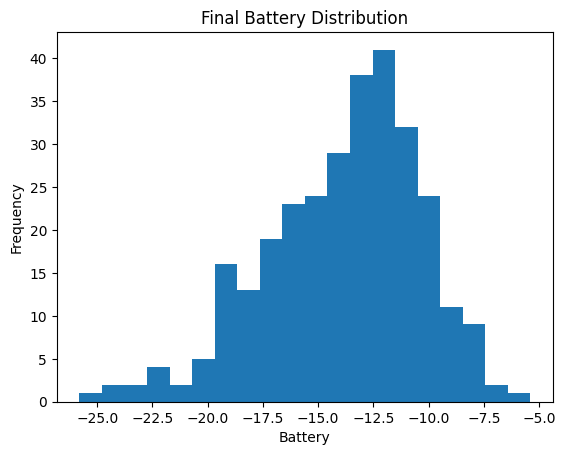

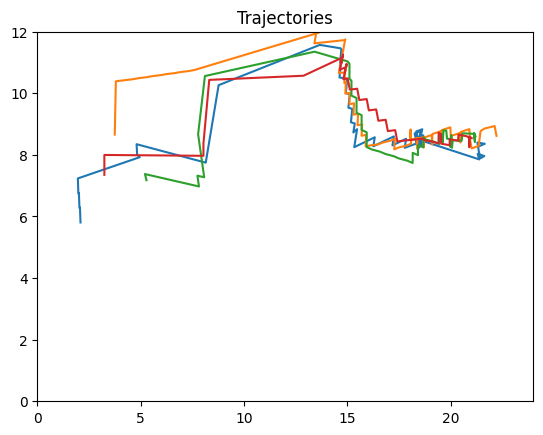


===== Q-Learning =====
0 -370.4670250000004
200 -370.46095000000025
400 -370.49155000000025
600 -370.46747500000026
800 -370.42922500000026
1000 -370.46162500000025
1200 -370.4915500000003
1400 -370.52147500000024
1600 -370.4753500000001
1800 -370.46590000000015
2000 -370.5100000000002
2200 -370.4895250000001
2400 -370.4236000000004
2600 -370.47985000000034
2800 -370.54285000000016
3000 -370.4839000000003
3200 -370.4353000000003
3400 -370.4429500000001
3600 -370.44407500000034
3800 -370.51495000000017
4000 -370.4987500000003
4200 -370.4733250000002
4400 -370.527775
4600 -370.47287500000016
4800 -370.46185000000025
5000 -370.4899750000003
5200 -370.42022500000024
5400 -370.51450000000017
5600 -370.55185
5800 -370.50212499999986
6000 -370.50010000000003
6200 -370.5334000000004
6400 -370.5084250000001
6600 -370.5104500000002
6800 -370.4861500000003
7000 -370.56759999999997
7200 -370.5014500000002
7400 -370.44767500000034
7600 -370.5127000000001
7800 -370.44002500000033
8000 -370.54059999

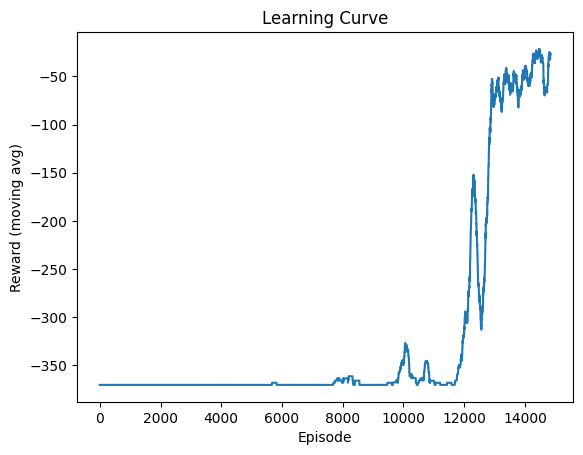

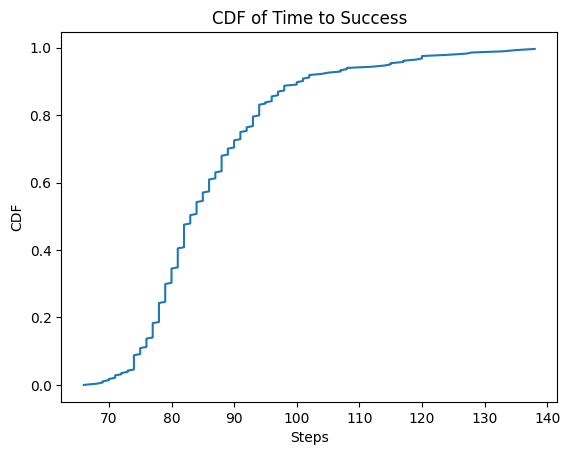

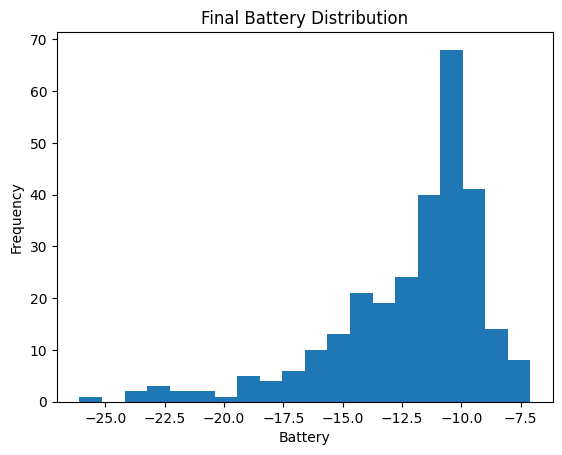

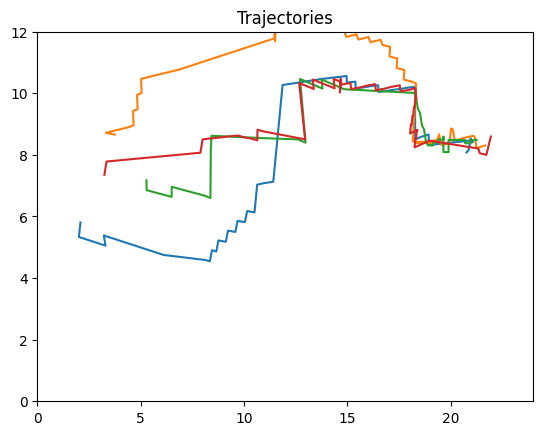


===== Prospect =====
0 -370.4670250000004
200 -370.4744500000003
400 -370.49380000000025
600 -370.4816500000003
800 -370.4591500000002
1000 -370.45667500000036
1200 -370.5192250000001
1400 -370.5088750000003
1600 -370.4913250000001
1800 -370.4922250000002
2000 -370.45082500000046
2200 -370.5158500000002
2400 -370.44137500000045
2600 -370.4967250000001
2800 -370.4339500000002
3000 -370.4956000000003
3200 -370.4776000000003
3400 -370.43507500000044
3600 -370.47445
3800 -370.48187500000023
4000 -370.49042500000024
4200 -370.4416000000003
4400 -370.4447500000002
4600 -370.5068500000002
4800 -370.61845000000034
5000 -370.4879500000002
5200 -370.5115750000001
5400 -370.5640000000001
5600 -370.4582500000004
5800 -370.46005000000014
6000 -370.44790000000035
6200 -370.53452500000003
6400 -370.5016750000004
6600 -370.46275000000026
6800 -370.4668000000004
7000 -370.5102250000002
7200 -370.4877250000004
7400 -370.55095000000017
7600 -370.50819999999993
7800 -370.5608500000001
8000 -370.543300000

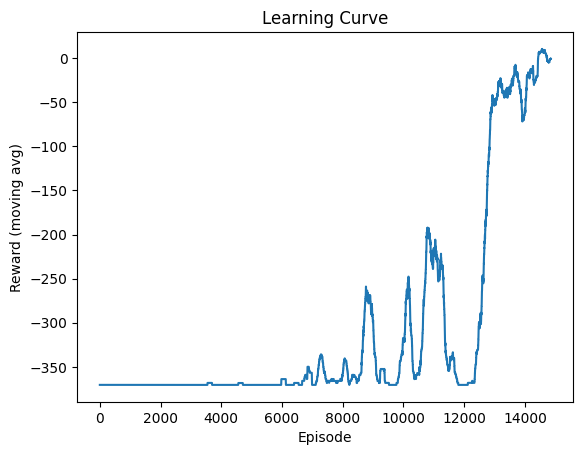

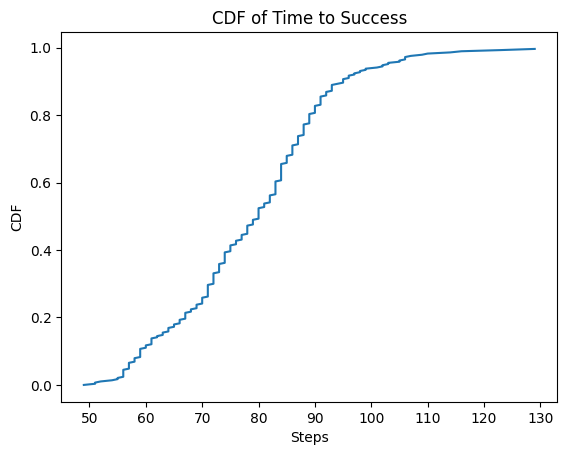

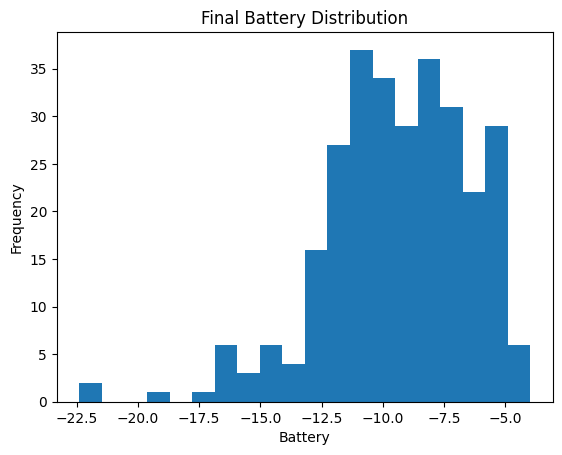

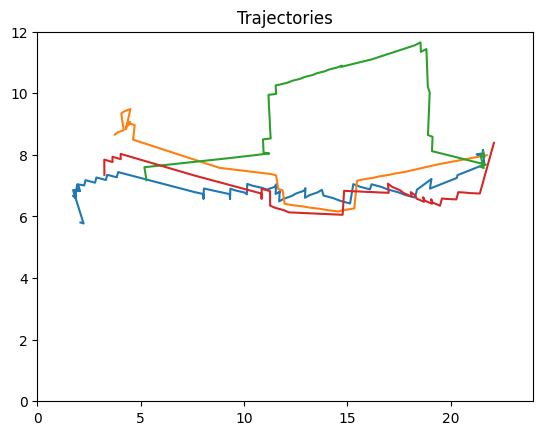


===== RiskSensitive =====
0 -370.4670250000004
200 -370.45127500000046
400 -370.45352500000024
600 -370.4926750000002
800 -370.45487500000024
1000 -370.4731000000004
1200 -370.46815000000026
1400 -370.4938000000001
1600 -370.44767500000046
1800 -370.4911000000003
2000 -370.4726500000004
2200 -370.4926750000001
2400 -370.4908750000002
2600 -370.58289999999965
2800 -370.53250000000014
3000 -370.45757500000036
3200 -370.51
3400 -370.48142500000023
3600 -370.4323750000004
3800 -370.4897500000001
4000 -370.52642499999996
4200 -370.4953750000002
4400 -370.50280000000015
4600 -370.4753500000002
4800 -370.4814250000002
5000 -370.5282250000001
5200 -370.4974
5400 -370.54082500000004
5600 -370.5001000000003
5800 -370.46995000000027
6000 -370.4575750000003
6200 -370.46327499999995
6400 -370.50730000000016
6600 -370.47917500000017
6800 -370.4774500000002
7000 -370.5534250000007
7200 -370.5201250000001
7400 -370.56692499999997
7600 -370.4989750000001
7800 -370.48750000000024
8000 -370.510225000000

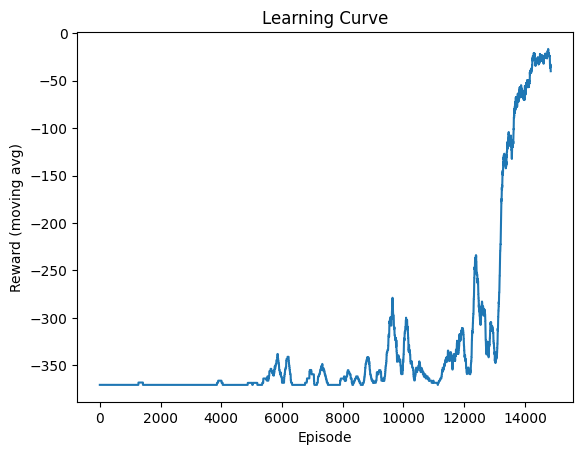

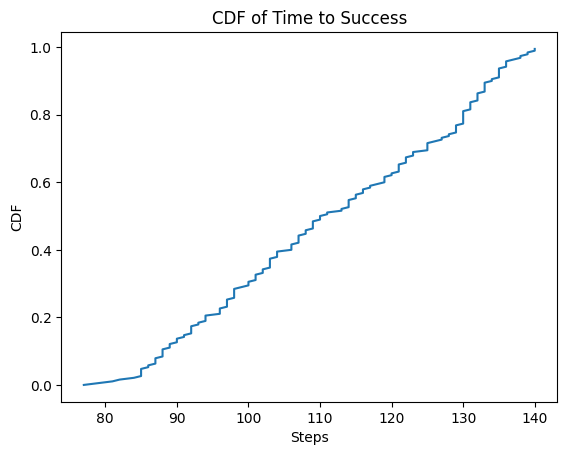

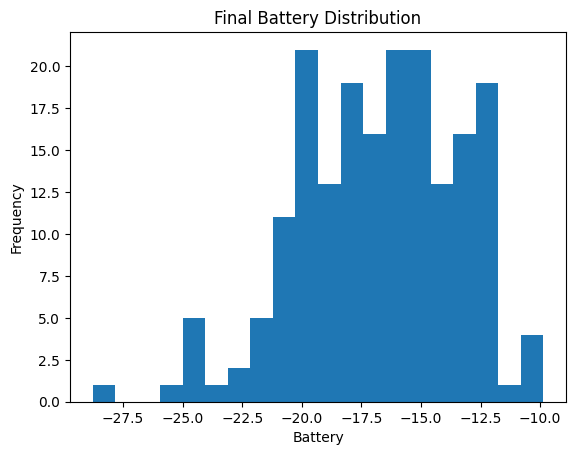

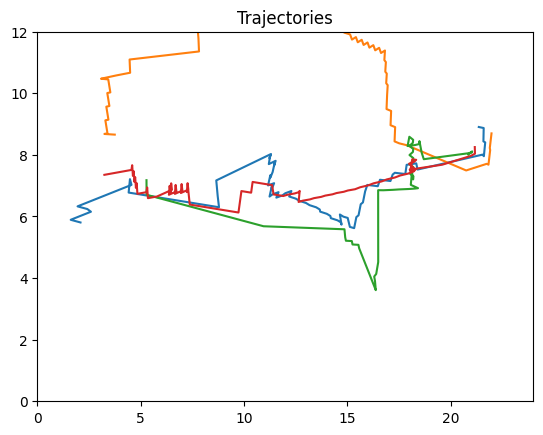


===== Q-Learning =====
0 -370.46882500000027
200 -370.4335000000002
400 -370.4924500000002
600 -370.4994250000001
800 -370.44250000000034
1000 -370.4951500000001
1200 -370.47265000000027
1400 -370.5183250000003
1600 -370.4661250000002
1800 -370.45892500000025
2000 -370.44542500000034
2200 -370.5012250000001
2400 -370.45060000000035
2600 -370.4922250000002
2800 -370.4962750000001
3000 -370.45667500000025
3200 -370.48480000000023
3400 -370.4965000000001
3600 -370.47670000000016
3800 -370.5343000000001
4000 -370.532275
4200 -370.51562500000006
4400 -370.4735500000003
4600 -370.49717499999997
4800 -370.5039250000001
5000 -370.46927500000015
5200 -370.54330000000004
5400 -370.50190000000026
5600 -370.51765000000023
5800 -370.51922500000006
6000 -370.4899750000001
6200 -370.52687500000025
6400 -370.5046000000003
6600 -370.4548750000005
6800 -370.5576999999998
7000 -370.4200000000003
7200 -370.4629750000002
7400 -370.4773750000001
7600 -370.5183250000003
7800 -370.51765000000046
8000 -370.48

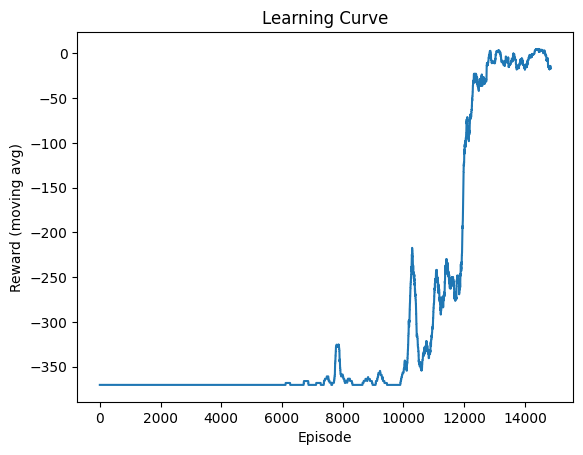

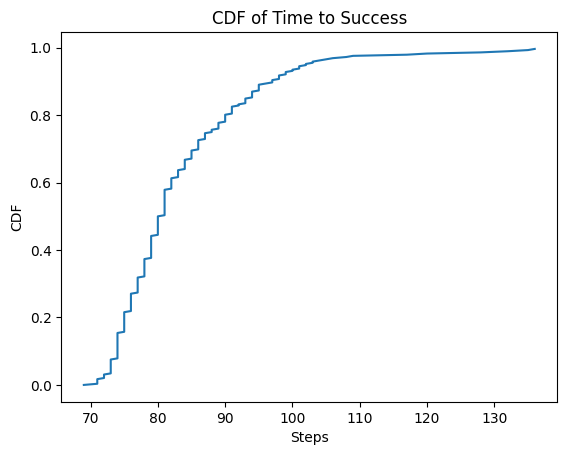

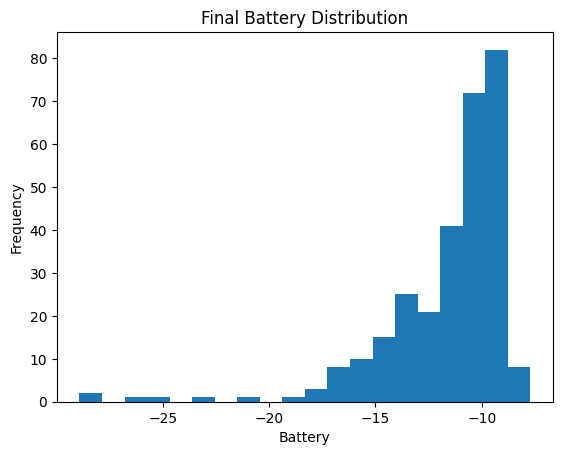

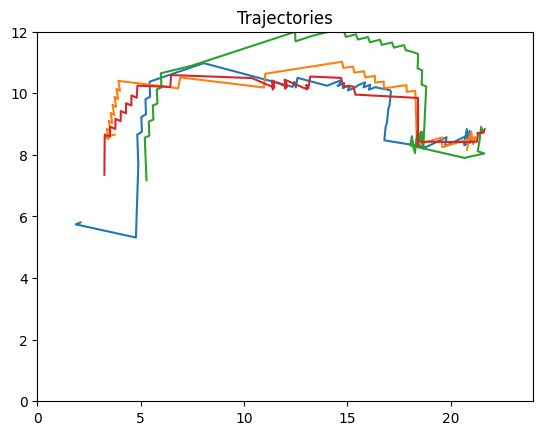


===== Prospect =====
0 -370.46882500000027
200 -370.47040000000015
400 -370.4647750000004
600 -370.4841250000002
800 -370.4762500000003
1000 -370.47850000000017
1200 -370.4971750000003
1400 -370.50100000000026
1600 -370.4688250000003
1800 -370.49740000000014
2000 -370.4850250000002
2200 -370.5201250000002
2400 -370.4758000000004
2600 -370.4965
2800 -370.5129250000001
3000 -370.4647750000005
3200 -370.44902500000035
3400 -370.466125
3600 -370.4728750000002
3800 -370.5052749999999
4000 -370.52507500000036
4200 -370.513375
4400 -370.5536500000002
4600 -370.5275500000002
4800 -370.45375000000024
5000 -370.5214749999998
5200 -370.52080000000007
5400 -370.47677500000015
5600 -370.4281000000004
5800 -370.5113500000002
6000 -370.4780500000003
6200 -370.46927500000027
6400 -370.4634250000002
6600 -370.4913250000002
6800 -370.46770000000026
7000 -370.5221500000001
7200 -370.5259750000001
7400 -370.5073000000003
7600 -370.4344000000002
7800 -370.4908750000001
8000 -370.556125
8200 -370.460950000

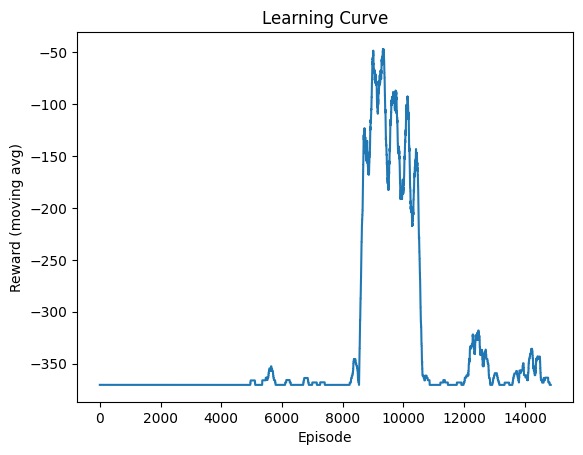

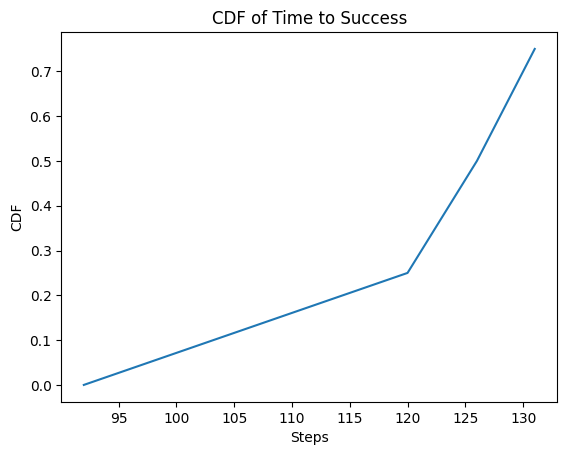

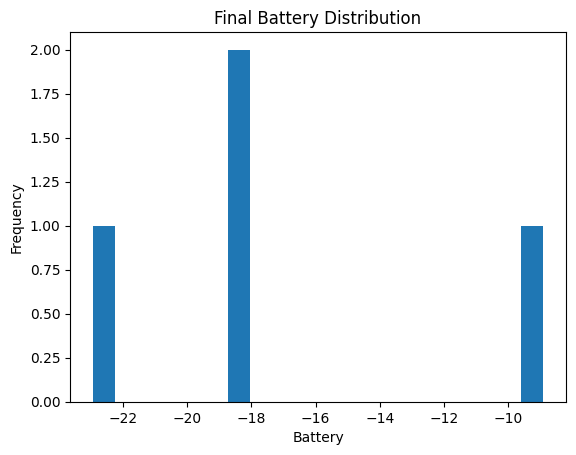

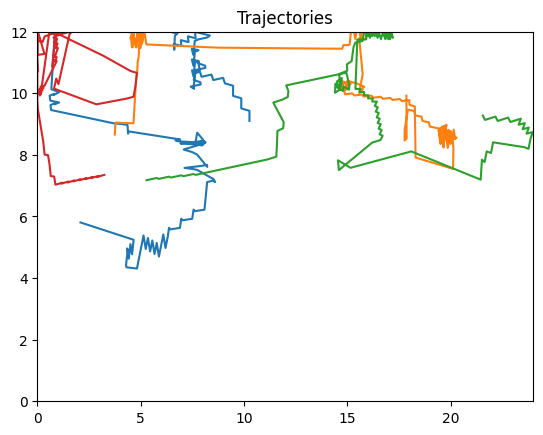


===== RiskSensitive =====
0 -370.46882500000027
200 -370.48322500000006
400 -370.45510000000036
600 -370.4893000000002
800 -370.47670000000033
1000 -370.4224750000003
1200 -370.48975000000013
1400 -370.5077500000003
1600 -370.4139250000003
1800 -370.53407500000003
2000 -370.5019000000002
2200 -370.53610000000015
2400 -370.52125000000024
2600 -370.4787250000004
2800 -370.49200000000036
3000 -370.45375000000035
3200 -370.45825000000025
3400 -370.51382500000017
3600 -370.44722500000034
3800 -370.4787250000003
4000 -370.5642250000001
4200 -370.4762500000001
4400 -370.5032500000003
4600 -370.4760250000003
4800 -370.46252500000014
5000 -370.52012500000006
5200 -370.4461000000003
5400 -370.4326000000002
5600 -370.49087500000024
5800 -370.52800000000025
6000 -370.46702500000026
6200 -370.49695000000037
6400 -370.47850000000017
6600 -13.319575000000086
6800 -370.53250000000014
7000 -370.5102250000002
7200 -370.51810000000023
7400 -370.5453250000003
7600 -370.4825500000003
7800 -370.54757500000

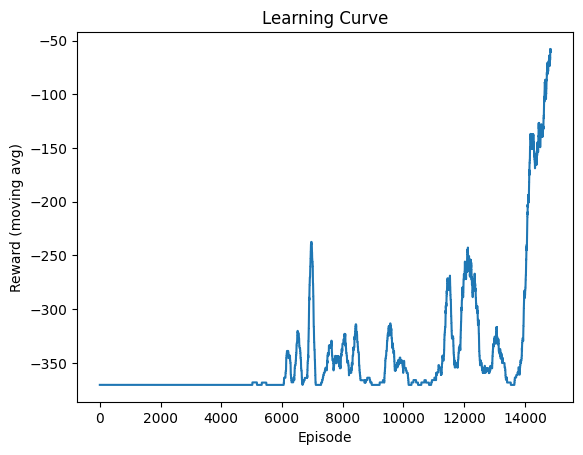

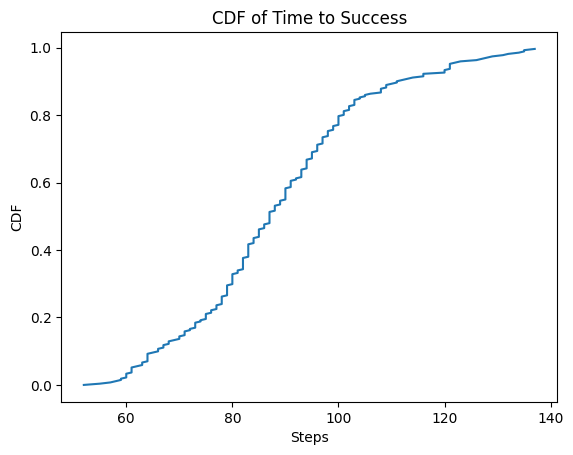

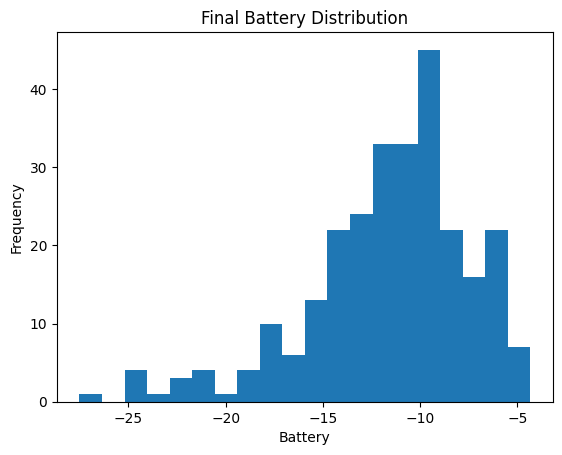

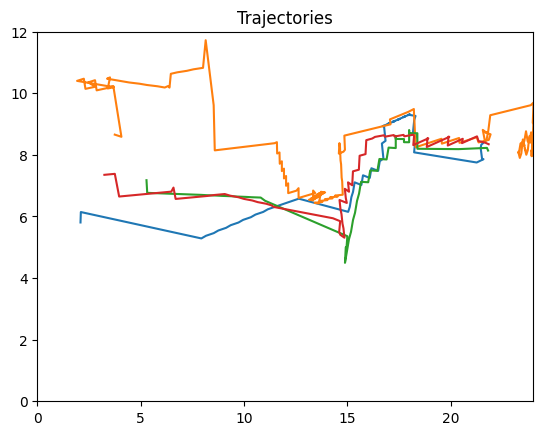


===== Q-Learning =====
0 -370.4330500000002
200 -370.45600000000024
400 -370.4944750000002
600 -370.46815000000015
800 -370.45645000000036
1000 -370.4458750000003
1200 -370.5187750000002
1400 -370.4953750000002
1600 -370.4962750000003
1800 -370.5149500000001
2000 -370.53115000000014
2200 -370.4848000000002
2400 -370.4269750000002
2600 -370.4258500000003
2800 -370.48165000000006
3000 -370.5700750000002
3200 -370.55095000000017
3400 -370.4314750000003
3600 -370.50392500000027
3800 -370.45195000000035
4000 -370.52282500000007
4200 -370.4803
4400 -370.5055000000002
4600 -370.45622500000036
4800 -370.4782750000001
5000 -370.5761499999999
5200 -370.41595000000035
5400 -370.48547500000024
5600 -370.54982500000017
5800 -370.52169999999984
6000 -370.4845750000001
6200 -370.4998750000002
6400 -370.5878499999999
6600 -370.48210000000023
6800 -370.4807500000002
7000 -370.45465000000024
7200 -370.49177500000036
7400 -370.49222500000013
7600 -370.4323750000003
7800 -370.4830000000003
8000 -370.5282

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


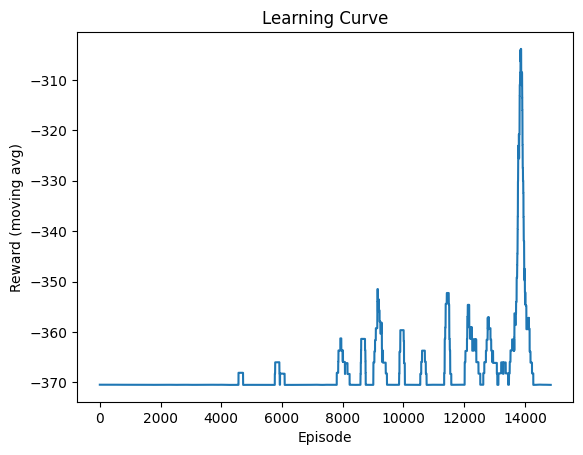

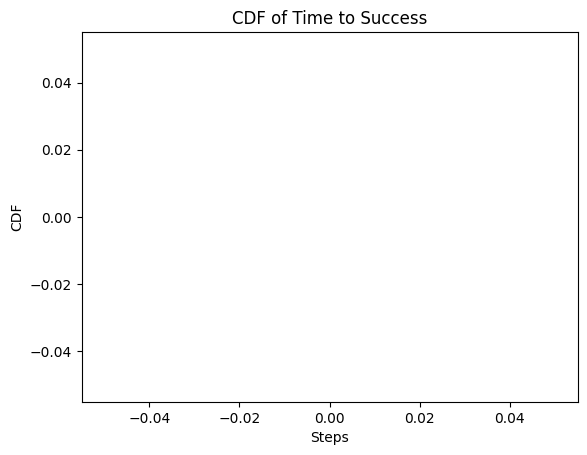

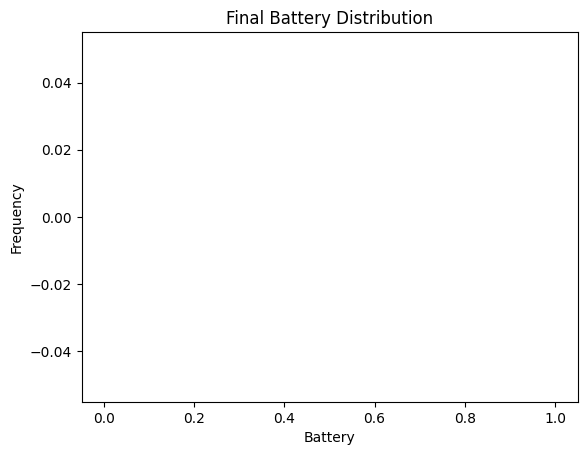

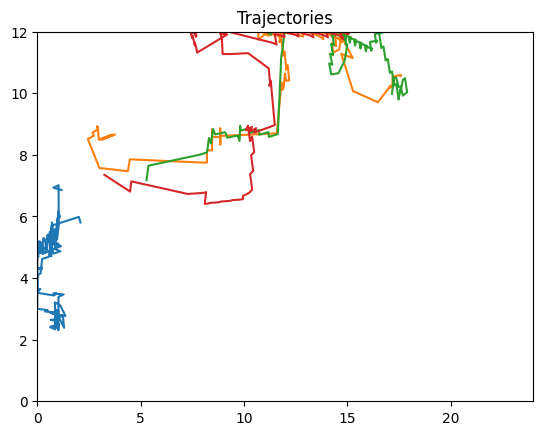


===== Prospect =====
0 -370.4330500000002
200 -370.48097500000017
400 -370.4897500000002
600 -370.46095
800 -370.47782500000034
1000 -370.44745000000023
1200 -370.4890750000002
1400 -370.4974000000002
1600 -370.4605000000004
1800 -370.4875000000002
2000 -370.5028000000002
2200 -370.50887500000033
2400 -370.4706250000002
2600 -370.4713000000004
2800 -370.5430750000003
3000 -370.4816500000002
3200 -370.54172500000016
3400 -370.52170000000024
3600 -370.4958250000003
3800 -370.4825500000003
4000 -370.4744500000003
4200 -370.46882500000027
4400 -370.5104500000001
4600 -370.45375000000035
4800 -370.4992000000002
5000 -370.53152500000044
5200 -370.4582500000001
5400 -370.5225250000002
5600 -370.4911000000001
5800 -370.5491500000003
6000 -370.44497500000034
6200 -370.5037000000003
6400 -370.50100000000015
6600 -370.4715250000002
6800 -370.5097750000002
7000 -370.50347500000015
7200 -370.4746750000004
7400 -370.599775
7600 -370.5250749999999
7800 -370.4299000000003
8000 -370.4526250000003
8200

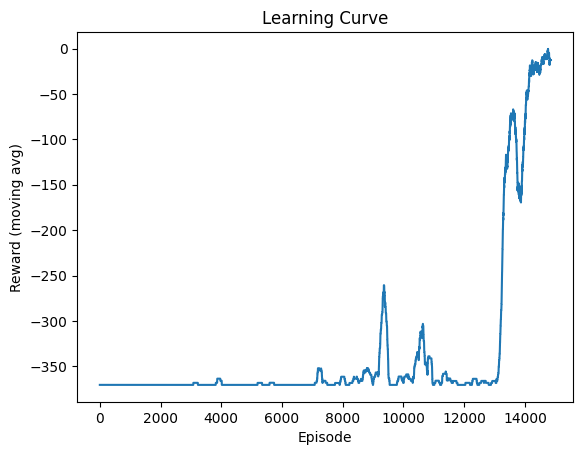

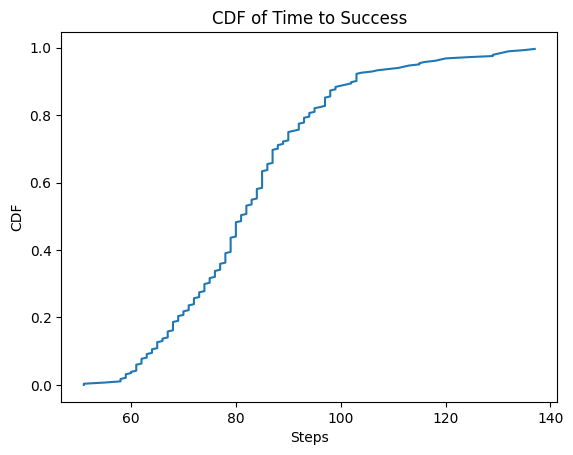

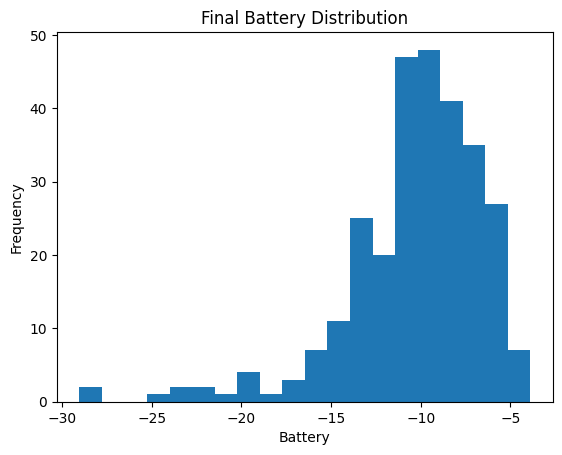

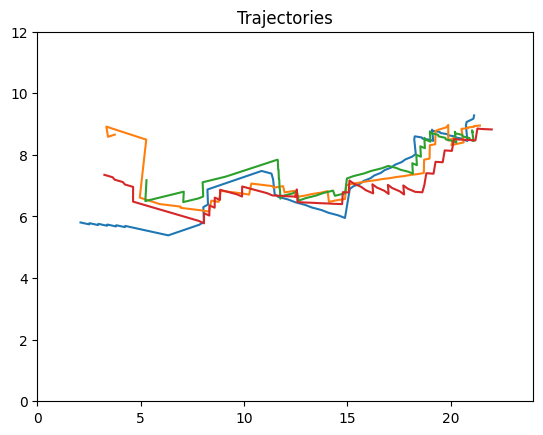


===== RiskSensitive =====
0 -370.4330500000002
200 -370.47850000000017
400 -370.4904250000001
600 -370.4551000000002
800 -370.4359750000003
1000 -370.5028000000002
1200 -370.46657500000026
1400 -370.4326000000004
1600 -370.43867500000033
1800 -370.4492500000003
2000 -370.51765000000023
2200 -370.47895000000017
2400 -370.5091
2600 -370.47175000000027
2800 -370.47940000000034
3000 -370.5282250000002
3200 -370.4877250000003
3400 -370.4965000000001
3600 -370.50212500000043
3800 -370.44880000000023
4000 -370.46590000000043
4200 -370.5012250000001
4400 -370.4692750000003
4600 -370.5444250000004
4800 -370.47152500000016
5000 -370.5061750000003
5200 -370.52260000000007
5400 -370.5840250000002
5600 -370.5075250000002
5800 -370.5194500000001
6000 -370.5059500000002
6200 -370.37012500000014
6400 -370.5181
6600 -370.5021250000002
6800 -370.4758000000002
7000 -370.4836750000001
7200 -370.5001000000001
7400 -370.44812500000023
7600 -370.52822500000036
7800 -370.5959499999998
8000 -370.4953750000002

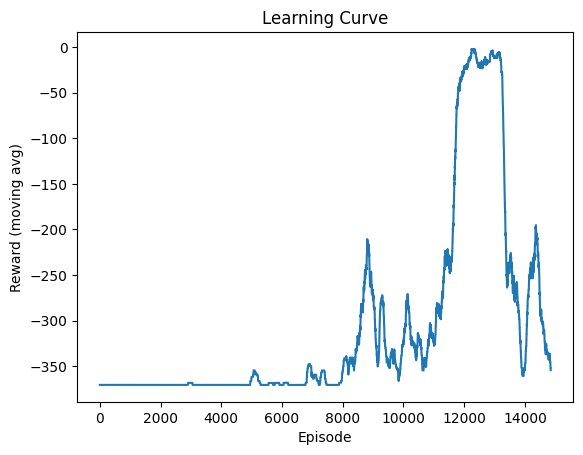

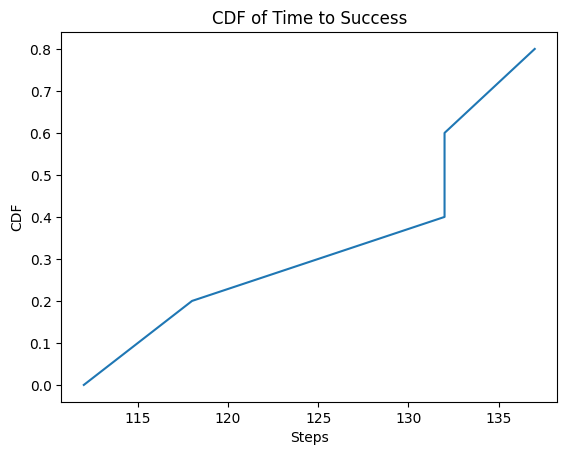

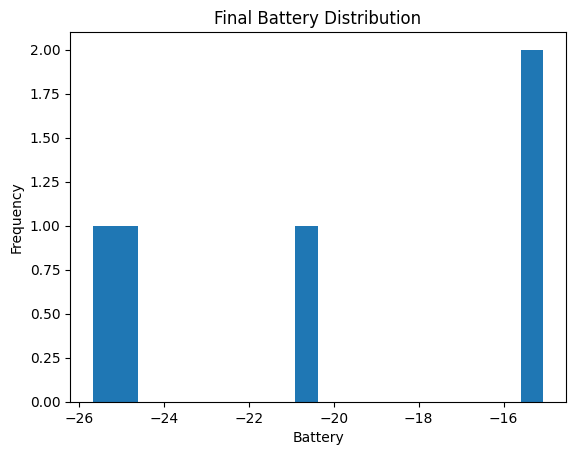

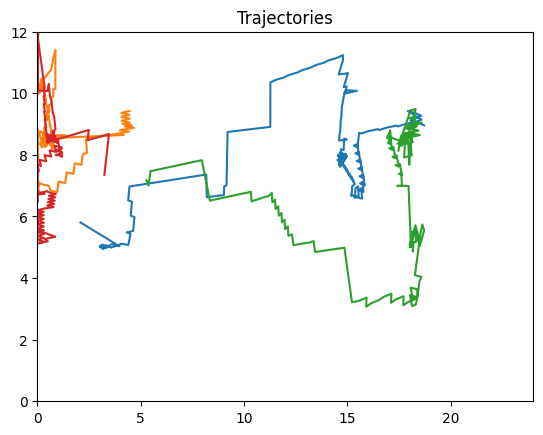


===== Q-Learning =====
0 -370.4987500000001
200 -370.45060000000035
400 -370.4569000000003
600 -370.4553250000003
800 -370.4976250000003
1000 -370.5235000000001
1200 -370.49425000000025
1400 -370.50707500000016
1600 -370.51855000000006
1800 -370.5228250000001
2000 -370.47445000000016
2200 -370.47940000000034
2400 -370.47040000000015
2600 -370.4677000000004
2800 -370.48030000000017
3000 -370.53587500000015
3200 -370.5421750000001
3400 -370.46387500000026
3600 -370.461175
3800 -370.4924500000002
4000 -370.47535000000016
4200 -370.5115749999999
4400 -370.48142500000006
4600 -370.45892500000036
4800 -370.5214750000001
5000 -370.4958250000001
5200 -370.50550000000015
5400 -370.4827750000003
5600 -370.4872750000002
5800 -370.52260000000024
6000 -370.5405999999999
6200 -370.4814250000001
6400 -370.4767000000003
6600 -370.4625250000005
6800 -370.4805250000003
7000 -370.5264250000002
7200 -370.46567500000026
7400 -370.52260000000035
7600 -370.501
7800 -370.54555000000016
8000 -370.440250000000

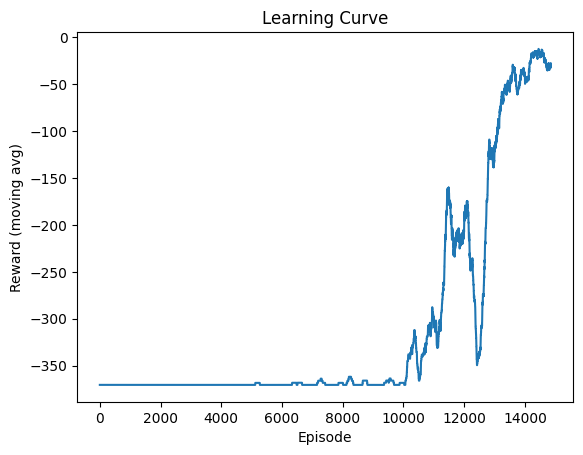

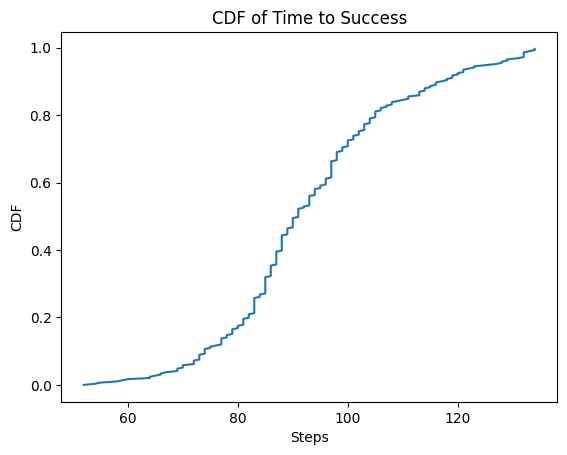

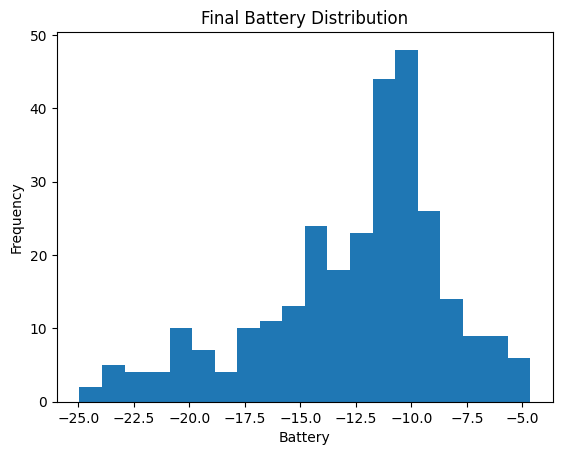

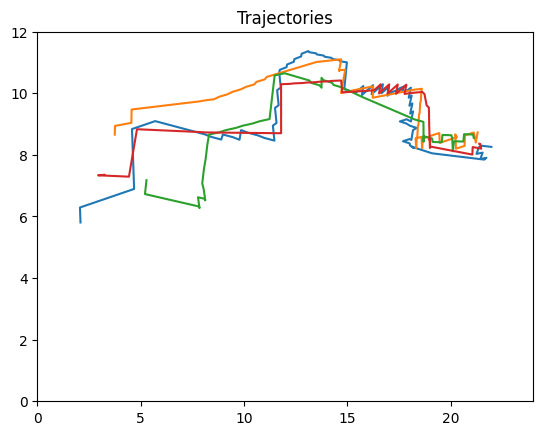


===== Prospect =====
0 -370.4987500000001
200 -370.45510000000036
400 -370.4890750000002
600 -370.4731000000002
800 -370.4996500000001
1000 -370.4881750000003
1200 -370.46117500000014
1400 -370.4605000000002
1600 -370.5091000000002
1800 -370.42472500000054
2000 -370.4004250000005
2200 -370.44790000000023
2400 -370.4339500000003
2600 -370.5219250000001
2800 -370.4926750000002
3000 -370.4868250000003
3200 -370.4989750000003
3400 -370.497175
3600 -370.43845000000016
3800 -370.49694999999997
4000 -370.5120250000002
4200 -370.4992000000003
4400 -370.49560000000014
4600 -370.5016750000002
4800 -370.5156250000001
5000 -370.49672500000037
5200 -370.52665000000025
5400 -370.48412500000023
5600 -370.4508250000001
5800 -370.5320500000001
6000 -370.49852500000003
6200 -370.51900000000035
6400 -370.5178750000001
6600 -370.54307500000033
6800 -370.5610750000003
7000 -370.53272500000026
7200 -370.4989750000002
7400 -370.5882999999998
7600 -370.5548500000001
7800 -370.4974000000002
8000 -370.47287500

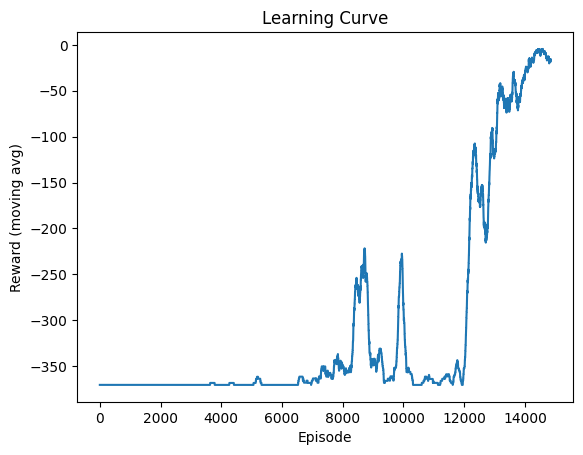

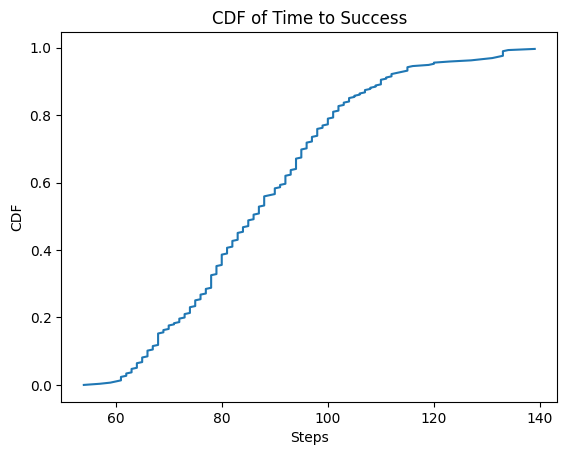

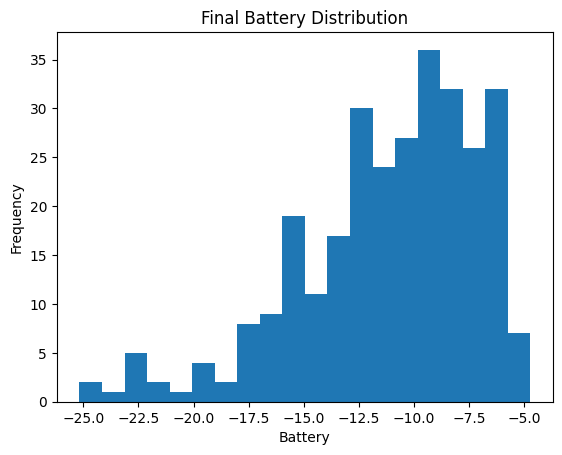

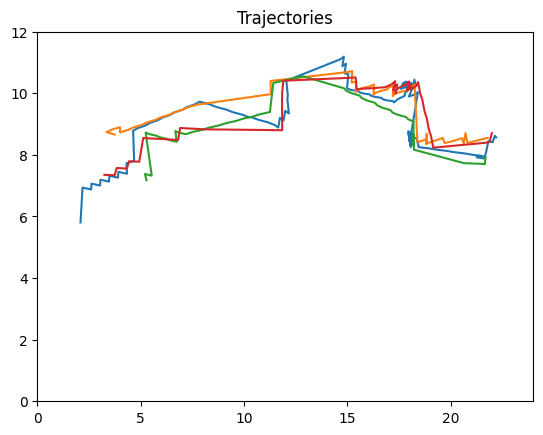


===== RiskSensitive =====
0 -370.4987500000001
200 -370.4627500000003
400 -370.4931250000002
600 -370.46072500000025
800 -370.5088750000002
1000 -370.4548750000004
1200 -370.514275
1400 -370.4744500000002
1600 -370.46905000000027
1800 -370.4886250000002
2000 -370.5145000000002
2200 -370.4580250000003
2400 -370.52575000000013
2600 -370.50280000000004
2800 -370.5086500000002
3000 -370.4987500000003
3200 -370.4841250000004
3400 -370.50775
3600 -370.5066250000002
3800 -370.48502500000023
4000 -370.46432500000026
4200 -370.5617500000005
4400 -370.4463250000003
4600 -370.52327499999996
4800 -370.46522500000003
5000 -370.5194500000001
5200 -370.4647750000005
5400 -370.46387500000003
5600 -370.51495000000017
5800 -370.5052750000001
6000 -370.50977499999993
6200 -370.51495000000034
6400 -370.5561250000002
6600 -370.4805250000003
6800 -370.46162500000037
7000 -370.5113500000002
7200 -370.4301250000002
7400 -370.4897500000003
7600 -370.50932500000033
7800 -370.46342500000026
8000 -11.27224999999

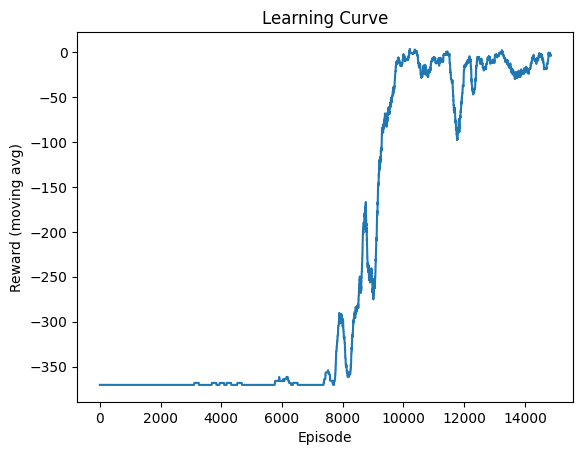

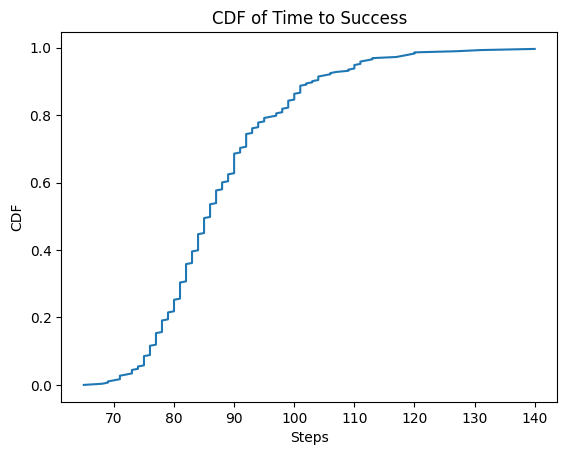

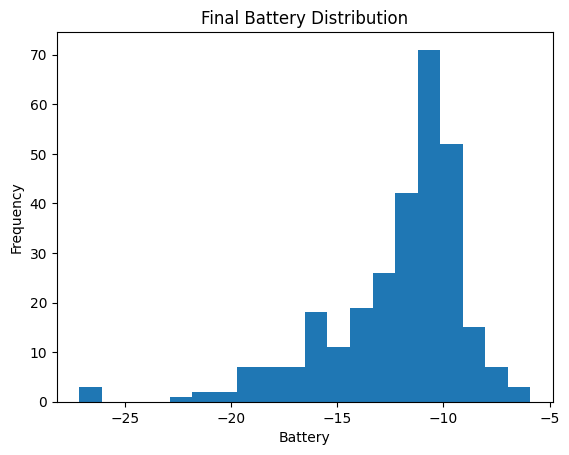

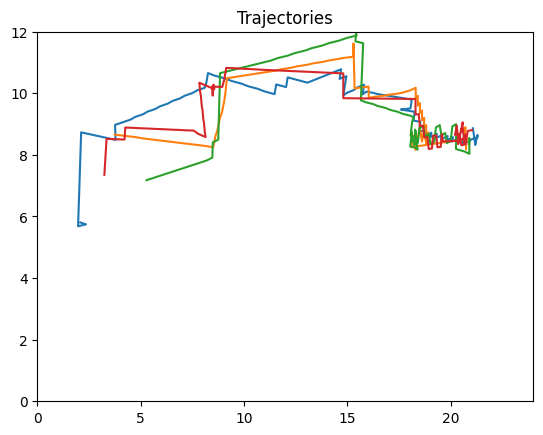

In [ ]:
agents = {
        "Q-Learning": lambda env: QLearningAgent(
            alpha=0.1, epsilon=1.0, discount=0.99, env=env
        ),
        "Prospect": lambda env: ProspectQLearningAgent(
            alpha=0.2, epsilon=1.0, discount=0.99, env=env
        ),
        "RiskSensitive": lambda env: RiskSensitiveQLearningAgent(
            alpha=0.2, epsilon=1.0, discount=0.99, env=env,
            n=0.05, reward_scale=5
        ),
    }
#agentQ = QLearningAgent(alpha=0.1, epsilon=1.0, discount=0.99, env=env)
#agentP = ProspectQLearningAgent(alpha=0.1, epsilon=1.0, discount=0.99, env=env)
#agentR = RiskSensitiveQLearningAgent(alpha=0.1, epsilon=1.0,  discount=0.99, env=env, n=0.05, reward_scale=20.0)
seeds = [ 42, 55, 68, 71, 84]
times = []
#seeds = [84]
for s in seeds:
  for name, agent_fn in agents.items():
    print(f"\n===== {name} =====")
    set_seed(s)
    env = DroneEnv(seed=s)
    agent = agent_fn(env)
    rewards = []


    for episode in range(15000):
        reward = train(env, agent, seed=s + episode)
        agent.epsilon = max(0.01, agent.epsilon * 0.997)
        rewards.append(reward)

        if episode % 200 == 0:
            print(episode, reward)
    results = evaluate_agent(env, agent)
    print(results)
    plot_learning_curve(rewards)
    plot_cdf(results["times"])
    times.append(results["times"])
    plot_battery_heatmap(results["energies"])
    plot_trajectories(env, agent)

In [ ]:
compare_agents(times[0], times[1])
compare_agents(times[1], times[2])
compare_agents(times[0], times[2])

t-stat: -24.99194805622243
p-value: 6.726325135722848e-84
Различие статистически значимо
t-stat: 13.61032508185136
p-value: 6.325073409164098e-35
Различие статистически значимо
t-stat: -13.266623876026467
p-value: 2.3649083622256712e-35
Различие статистически значимо


{'success_rate': 0.98, 'mean_time': np.float64(88.10204081632654), 'mean_energy': np.float64(-12.242956494105192), 'collision_rate': np.float64(0.3197278911564626), 'times': [86, 82, 87, 87, 87, 100, 84, 92, 71, 71, 84, 84, 91, 101, 99, 82, 116, 85, 84, 104, 95, 89, 83, 84, 139, 112, 89, 89, 92, 96, 86, 93, 76, 106, 88, 95, 85, 84, 84, 104, 90, 88, 90, 99, 78, 77, 78, 122, 88, 104, 75, 98, 81, 89, 84, 80, 83, 99, 88, 80, 94, 101, 87, 117, 81, 90, 91, 88, 76, 93, 75, 74, 96, 91, 83, 90, 78, 91, 83, 117, 104, 92, 112, 94, 92, 102, 90, 86, 77, 79, 79, 90, 83, 94, 87, 98, 82, 97, 79, 85, 83, 84, 82, 70, 92, 78, 106, 82, 110, 73, 92, 73, 77, 82, 83, 82, 82, 77, 91, 85, 69, 112, 82, 90, 82, 83, 87, 82, 100, 83, 100, 77, 90, 85, 76, 105, 113, 80, 91, 84, 82, 77, 73, 79, 92, 119, 78, 111, 91, 100, 84, 76, 83, 78, 80, 85, 81, 78, 83, 92, 84, 98, 84, 88, 74, 92, 81, 94, 96, 77, 83, 77, 86, 93, 81, 79, 82, 75, 63, 85, 73, 70, 77, 88, 99, 82, 87, 111, 93, 78, 83, 88, 76, 82, 92, 78, 93, 100, 112, 

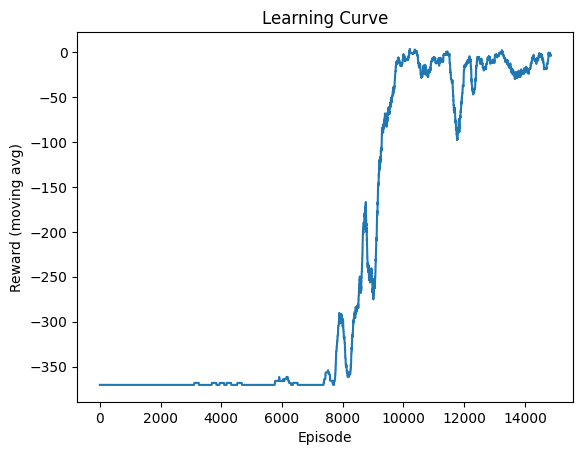

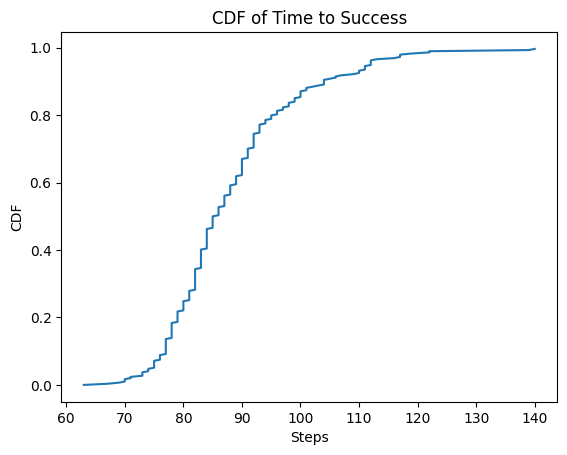

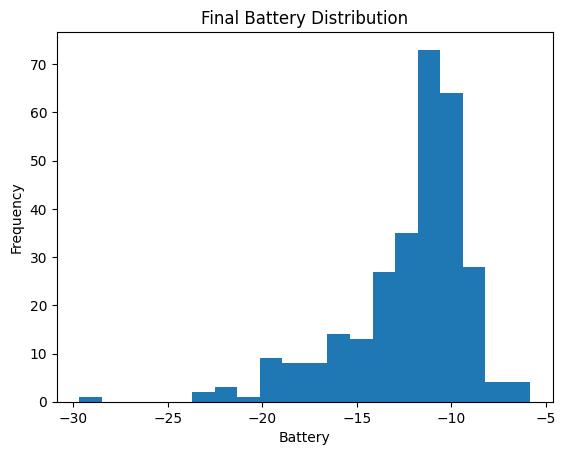

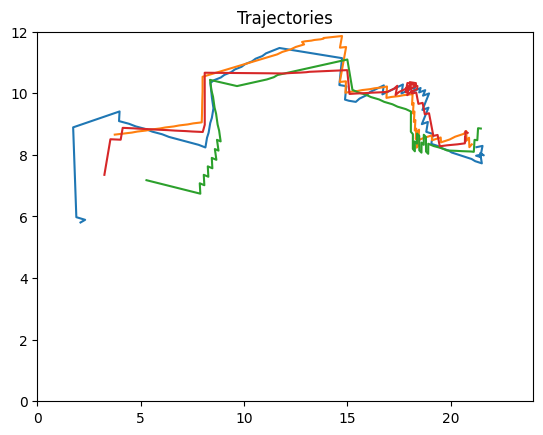

In [ ]:
results = evaluate_agent(env, agent)
print(results)
plot_learning_curve(rewards)
plot_cdf(results["times"])
plot_battery_heatmap(results["energies"])
plot_trajectories(env, agent)